# Generating Observed Data via Deepwave

This notebook builds a synthetic ("observed") seismic dataset that is used as the reference/target data for the Full Waveform Inversion (FWI) workflow of this package.

The general pipeline implemented here is:

1. Load and downsample a reference sound-speed (velocity) model.
2. Define an acquisition geometry (source and receiver positions).
3. Build a Ricker wavelet as the source time function.
4. Propagate the wavefield through the true velocity model using [Deepwave](https://github.com/ar4/deepwave)'s scalar wave-equation solver.
5. Inspect the modeled shot gathers.
6. Export the resulting synthetic data (together with acquisition metadata) to a Zarr dataset, which is consumed by later stages of the inversion pipeline (e.g., the FWI notebook).

The libraries imported below provide, respectively: plotting (`matplotlib`), tensor operations and automatic differentiation (`torch`), execution-time profiling (`time`), array handling (`numpy`), the acoustic wave-equation propagator (`deepwave`), labeled multi-dimensional array storage (`xarray`), tensor interpolation utilities (`torch.nn.functional`), and image smoothing (`scipy.ndimage.gaussian_filter`, used later for model regularization).

In [1]:
# Plotting
import matplotlib.pyplot as plt
# Tensor operations, autograd, and Deepwave's backend
import torch
# Used to measure the execution time of the forward-modeling workflow
import time
# Array handling and I/O (reading the binary velocity model)
import numpy as np
# Acoustic wave-equation propagator
import deepwave
from deepwave import scalar
# Labeled multi-dimensional arrays, used to package and export the synthetic data
import xarray as xr
# Interpolation utilities (used to downsample the velocity model)
import torch.nn.functional as F
# Gaussian smoothing (available for model regularization, if needed)
from scipy.ndimage import gaussian_filter

import sys
import os

# Get the absolute path (root of the project) and add to the path
caminho_raiz = os.path.abspath(os.path.join(os.getcwd(), '..'))
if caminho_raiz not in sys.path:
    sys.path.append(caminho_raiz)

from ocean_inversion.config import (
                                MONTH_TARGET,FOLDER_NAME,FOLDER_OUTPUT,    
                                MODEL_VP0, MODEL_RHO0, MODEL_EOFS, MODEL_COEF_HIST,
                                N_EOFS, Z_MAX, DZ,MARGEM_COEF

				                )

[ocean_inversion.config] Reading configuration file: /home/sysop/diogogit/NFH_inversion_seismic_oceanography/config_file.cnf


# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [2]:
data_path = FOLDER_OUTPUT+FOLDER_NAME+'/DATA/'
os.makedirs(data_path,exist_ok=True)

### Directory for saving figures: 

In [3]:
figures_path = FOLDER_OUTPUT+FOLDER_NAME+'/FIGURES/'
os.makedirs(figures_path,exist_ok=True)

# Parameters configuration

This section loads the reference ("true") velocity model from a binary file and prepares it for use by Deepwave.

Key steps performed in the cell below:

- The original (high-resolution) model is read from disk as a flat `float32` binary array and reshaped into its original grid dimensions (`ny_old` x `nx_old`), sampled at `dx_old`.
- A subregion of interest is cropped from the full model, limited to a maximum depth (`z_max`) and horizontal extent (`x_max`), both given in meters.
- The cropped model is downsampled onto a coarser simulation grid (`ny` x `nx`) with spacing `dx`, using bilinear interpolation (`torch.nn.functional.interpolate`). This coarser grid is what will actually be used in the wave propagation, keeping the computational cost tractable.
- The resulting tensor `v` is the velocity model that will be treated as the "true"/observed model when generating the synthetic data.

**Note:** the path passed to `np.fromfile` is a local, machine-specific path; when using this cell in the package it should be replaced with a path (or configuration parameter) pointing to the user's own velocity model file.

In [4]:
# Run everything on CPU (change to "cuda" if a GPU is available)
device = torch.device("cpu")

# Dimensions and grid spacing of the original (full-resolution) velocity model
ny_old = 2501       # number of grid points in depth (Z) in the original model
nx_old = 5564        # number of grid points in the horizontal direction (X) in the original model
dx_old = [1, 2]      # original grid spacing [depth, horizontal], in meters
dx = [5, 5]          # grid spacing [depth, horizontal] to be used in the simulation, in meters

# Load the original velocity model from a flat binary file and reshape it
# to its original grid dimensions (depth x horizontal)
v_numpy = np.fromfile("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/modelo_inicial/sound_speed.bin", dtype=np.float32).reshape(ny_old, nx_old)

# Z_max = 2 km = 2000 m = the maximum depth of the target model 
z_max = 2000   # maximum depth (m) of the cropped region of interest
x_max = 200    # maximum horizontal extent (m) of the cropped region of interest

# Crop the original model down to the region of interest
v_numpy_cut = v_numpy[:z_max, :x_max]

# Number of grid points of the (coarser) simulation grid, based on the target spacing dx
ny = round(z_max/dx[1])
nx = round(x_max/dx[0])

# Convert the cropped model to a PyTorch tensor
v_true = torch.from_numpy(v_numpy_cut).to(device)

# Add batch and channel dimensions so it can be used with F.interpolate
v_true_4d = v_true.unsqueeze(0).unsqueeze(0)  # (1,1,ny,nx)

# Downsample (bilinear interpolation) the true model onto the coarser simulation grid
v_coarse = F.interpolate(v_true_4d,size=(ny, nx),mode='bilinear',align_corners=False)

# Remove the extra dimensions, detach from any prior graph, and enable gradient
# tracking (useful later for gradient-based inversion / FWI)
v_coarse = v_coarse.squeeze().detach().requires_grad_()

# Final velocity model used as the "true" model for generating the synthetic data
v = v_coarse


### Visualizing the original velocity model

Before cropping and downsampling, it is useful to inspect the full-resolution original velocity model (`v_numpy`, sampled at `dx_old`). The plot below shows the entire model in physical units (meters), with a red rectangle marking the region that is subsequently cropped (`z_max` x `x_max`) and used as the "true" model for the simulation.

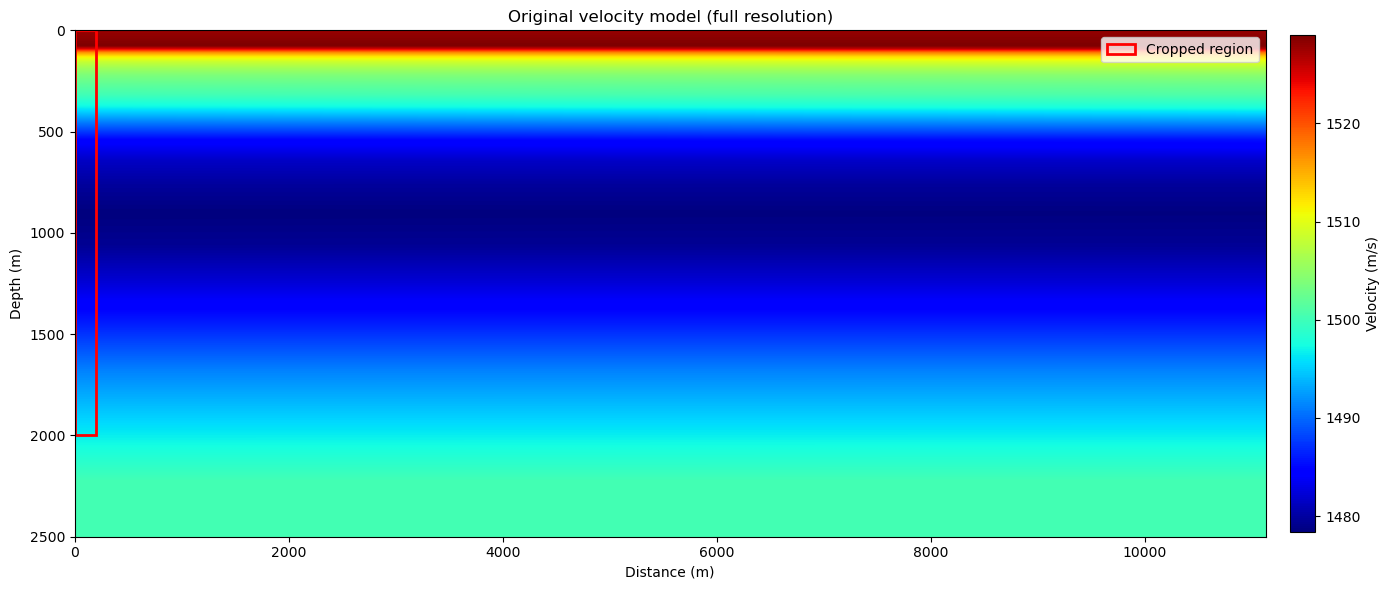

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Physical extent of the original model, in meters: [x_min, x_max, z_max, z_min]
# (z_min is placed last so that depth increases downward in the plot)
extent_old = [0, nx_old * dx_old[1], ny_old * dx_old[0], 0]

# Display the full-resolution original velocity model
im = ax.imshow(v_numpy, cmap="jet", aspect="auto", extent=extent_old)
ax.set_title("Original velocity model (full resolution)")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

# Highlight the region that is cropped and used as the "true" model
from matplotlib.patches import Rectangle
crop_rect = Rectangle((0, 0), x_max, z_max, linewidth=2, edgecolor="red",
                       facecolor="none", label="Cropped region")
ax.add_patch(crop_rect)
ax.legend(loc="upper right")

# Single colorbar for the velocity values
cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Velocity (m/s)")

plt.tight_layout()
fig.savefig(figures_path+"original_velocity_model.png", dpi=150)

## Creating the acquisition geometry

This cell defines the basic parameters of the seismic acquisition that will be simulated:

- `n_shots`: number of source positions (shots) to simulate.
- `n_sources_per_shot` / `d_source` / `first_source` / `source_depth`: number, spacing, starting position, and depth of the sources.
- `n_receivers_per_shot` / `d_receiver` / `first_receiver` / `receiver_depth`: number, spacing, starting position, and depth of the receivers associated with each shot.
- `freq`: dominant/peak frequency (Hz) of the source wavelet.
- `nt` / `dt`: number of time steps and time-step size (s) used in the finite-difference propagation; together they set the total recording time.
- `peak_time`: time (s) at which the Ricker wavelet reaches its peak amplitude.
- `pml_list`: width (in grid points) of the Perfectly Matched Layer (PML) absorbing boundaries on each side of the model (order: top, bottom, left, right), used to suppress artificial reflections from the edges of the domain.

For more info see: https://ausargeo.com/deepwave/example_forward_model

In [6]:
# Number of shots (source positions) to simulate
n_shots = 2

# Source configuration
n_sources_per_shot = 1   # number of sources fired per shot
d_source = 20             # spacing between consecutive shots (m)
first_source = 1          # horizontal position of the first source (m)
source_depth = 1          # depth at which all sources are placed (m)

# Receiver configuration
n_receivers_per_shot = 1  # number of receivers recording each shot
d_receiver = 2             # spacing between consecutive receivers within a shot (m)
first_receiver = 5         # horizontal position of the first receiver, relative to the shot (m)
receiver_depth = 1         # depth at which all receivers are placed (m)

# Source wavelet / time-stepping parameters
freq = 30                  # dominant/peak frequency of the source wavelet (Hz)
nt = 2001                  # number of time steps to propagate (sets the recording length)
dt = 0.002                 # time-step size (s)
peak_time = 1.5 / freq     # time (s) at which the Ricker wavelet reaches its peak amplitude

# Width (grid points) of the absorbing PML boundary on each side: [top, bottom, left, right]
pml_list = [0, 20, 20, 20]



### Execution timer

A simple timer is started here (`time1`) so that the total elapsed time of the forward-modeling workflow can be reported later in the notebook, once the wave propagation and plotting are complete.

In [7]:
# -------------------------
# Start a timer to measure how long the geometry setup and wave propagation take
# -------------------------
time1 = time.time()


# Seismic acquisition geometry configuration

With the acquisition parameters defined above, this section builds the tensors that Deepwave expects to describe source and receiver positions.

- `source_locations`: an integer tensor of shape `(n_shots, n_sources_per_shot, 2)`, where the last dimension stores the `(depth, horizontal position)` grid indices of each source. Sources are placed at a fixed `source_depth` and spread horizontally with spacing `d_source`, starting at `first_source`.
- `receiver_locations`: an integer tensor of shape `(n_shots, n_receivers_per_shot, 2)`, initialized here with zeros and populated with the actual receiver positions in the next section.

In [8]:
# Allocate the source-location tensor: (n_shots, n_sources_per_shot, 2),
# where the last dimension stores [depth_index, horizontal_index] in grid points
source_locations = torch.zeros(
    n_shots,
    n_sources_per_shot,
    2,
    dtype=torch.long,
    device=device,
)
# All sources are placed at a fixed depth
source_locations[..., 0] = source_depth
# Sources are spread horizontally with spacing d_source, starting at first_source
source_locations[:, 0, 1] = torch.arange(n_shots) * d_source + first_source


In [9]:
# Allocate the receiver-location tensor: (n_shots, n_receivers_per_shot, 2),
# where the last dimension stores [depth_index, horizontal_index] in grid points.
# Values are filled in the next cell.
receiver_locations = torch.zeros(
    n_shots,
    n_receivers_per_shot,
    2,
    dtype=torch.long,
    device=device,
)


## Receiver location configuration

This cell fills in the `receiver_locations` tensor:

- All receivers are placed at a fixed `receiver_depth`.
- `base_receivers` defines the horizontal offsets of the receivers within a single shot gather (spacing `d_receiver`, starting at `first_receiver`).
- `shot_displacement` shifts the whole receiver spread horizontally for each shot, so that the receiver array moves together with the source (a common "fixed offset"/moving-spread acquisition pattern).
- The final horizontal receiver positions are the sum of the base pattern and the per-shot displacement.

In [10]:
# All receivers are placed at a fixed depth
receiver_locations[..., 0] = receiver_depth

# Horizontal offsets of the receivers within a single shot gather
base_receivers = torch.arange(n_receivers_per_shot, device=device) * d_receiver + first_receiver
# Horizontal displacement of the whole receiver spread for each shot
# (the receiver array moves together with the source)
shot_displacement = (torch.arange(n_shots, device=device) * d_source).unsqueeze(1)

# Final horizontal receiver positions: base pattern + per-shot displacement
receiver_locations[:, :, 1] = base_receivers + shot_displacement


### Visualizing the acquisition geometry

Before running the simulation, it is useful to visually check that the velocity model, source positions, and receiver positions are consistent with each other. The cell below plots the (smoothed/downsampled) velocity model as a background image and overlays the source (red stars) and receiver (black triangles) positions in physical units (meters).

-------------------------
Generating acquisition plot




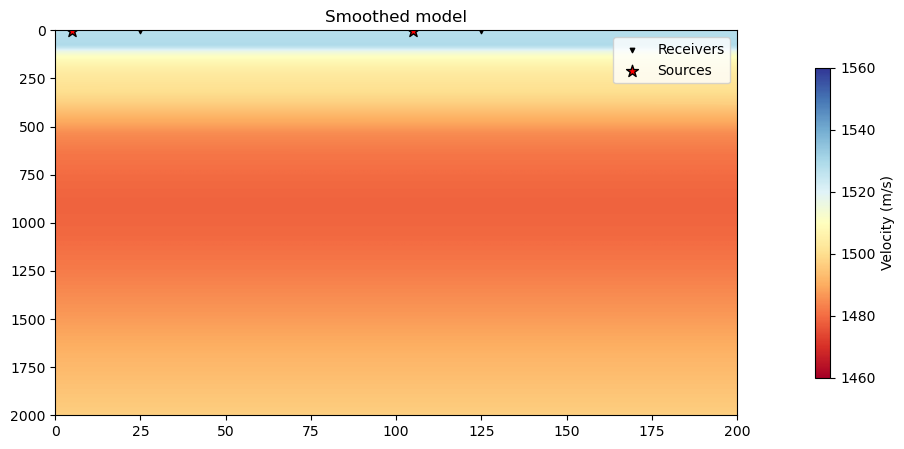

In [11]:
# --------------
# Plot acquisition geometry
# --------------
print('-------------------------')
print('Generating acquisition plot')
print('\n')

# Prepare the tensors for plotting
v_init_plot = v.detach().cpu().numpy()

# Extract the receiver and source coordinates
# Index 0 is Y (depth) and index 1 is X (horizontal distance)
# flatten() turns the array into a simple vector (list of points)

sx = source_locations[:, :, 1].cpu().numpy().flatten()*dx[1]
sy = source_locations[:, :, 0].cpu().numpy().flatten()*dx[0]

rx = receiver_locations[:, :, 1].cpu().numpy().flatten()*dx[1]
ry = receiver_locations[:, :, 0].cpu().numpy().flatten()*dx[0]

# Set the color limits for the velocity display
vmin_perfil = 1460
vmax_perfil = 1560

fig_models, ax = plt.subplots(1,1, figsize=(10, 5), sharex=True, sharey=True)

# Plot 1: smoothed/downsampled model
im = ax.imshow(v_init_plot,extent=[0, nx*dx[1], ny*dx[0], 0],aspect="auto",cmap="RdYlBu",vmin=vmin_perfil,vmax=vmax_perfil)
ax.set_title("Smoothed model")
ax.scatter(rx, ry, c='black', marker='v', s=10, label='Receivers')
ax.scatter(sx, sy, c='red', marker='*', s=80, edgecolors='black', label='Sources')
ax.legend(loc="upper right")

# Single colorbar for the plot
cbar = fig_models.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.1)
cbar.set_label("Velocity (m/s)")
fig_models.savefig(figures_path+"smoothed__model.png", dpi=150)

# Source modeled as Ricker Wavelet

The source time function used to excite the wavefield is a Ricker wavelet (named after Norman H. Ricker [1896-1980], American geophysicist), a zero-phase pulse commonly used in seismic modeling because of its compact support and well-defined dominant frequency.

`deepwave.wavelets.ricker` generates this wavelet from the `freq`, `nt`, `dt`, and `peak_time` parameters defined earlier, and the resulting waveform is repeated for every shot and every source per shot so that `source_amplitudes` has the shape `(n_shots, n_sources_per_shot, nt)` expected by Deepwave.

The number of time steps used to propagate the wavefield (and therefore the length of the recorded receiver data) is determined by the length of this source amplitude array (`nt`).

In [12]:
# Build the Ricker source wavelet and repeat it for every shot and every
# source per shot, giving shape (n_shots, n_sources_per_shot, nt)
source_amplitudes = (deepwave.wavelets.ricker(freq, nt, dt, peak_time).repeat(n_shots, n_sources_per_shot, 1).to(device))


### Visualizing the source wavelet

The cell below extracts the source wavelet used for the first shot/source pair and plots its amplitude as a function of time, which is useful for sanity-checking the wavelet's shape, polarity, and peak time before running the full simulation.

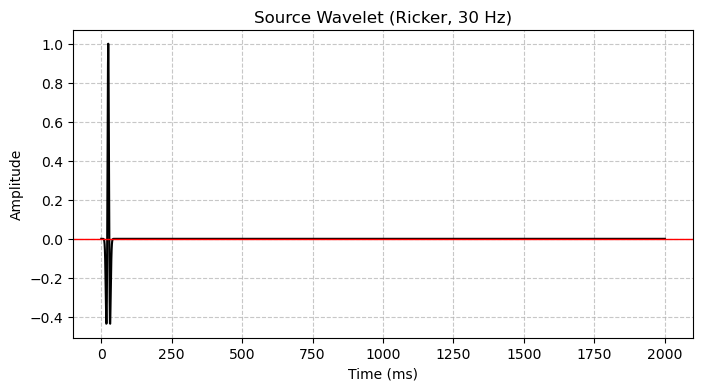

In [13]:
# 1. Extract the wavelet for the first shot [0] and the first source [0]
# 2. Move it from GPU to CPU with .cpu()
# 3. Convert it to a NumPy array with .numpy()
wave = source_amplitudes[0, 0, :].cpu().numpy()

# Build the time axis (in seconds) by multiplying the sample index by dt
time_axis = np.arange(nt) * dt

# Plot the wavelet
plt.figure(figsize=(8, 4))
plt.plot(time_axis/dt, wave, color='black', linewidth=1.5)

# Plot styling
plt.title(f'Source Wavelet (Ricker, {freq} Hz)')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the zero line to make the pulse easier to read
plt.axhline(0, color='red', linewidth=1, linestyle='-')

plt.show()


# Call Deepwave to propagate

This is the core forward-modeling step: Deepwave's `scalar` function solves the acoustic (constant-density) scalar wave equation using finite differences, given the velocity model `v`, grid spacing `dx`, time step `dt`, source wavelet(s), and source/receiver geometry.

Notable options used here:

- `accuracy=8`: 8th-order accurate spatial finite differences, chosen to keep numerical dispersion as low as possible.
- `pml_width=pml_list`: width of the absorbing (PML) boundary on each side of the domain, as defined earlier.
- `pml_freq=freq`: the dominant frequency passed to the PML formulation; supplying this (optional) parameter helps minimize spurious reflections from the domain edges.

The function returns a tuple of wavefield/state tensors; the last element (`out[-1]`) contains the recorded receiver amplitudes (the simulated seismic data) for all shots.

In [14]:
# Propagate the wavefield through the true velocity model with Deepwave's
# scalar (acoustic, constant-density) finite-difference solver
out = scalar(
    v,                                  # velocity model
    dx,                                 # grid spacing [depth, horizontal] (m)
    dt,                                 # time-step size (s)
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=8,                         # 8th-order accurate spatial finite differences
    pml_width=pml_list,                 # PML absorbing boundary width (grid points)
    pml_freq=freq                       # dominant frequency passed to the PML
)


### Checking the output shape

A quick check of the shape of the simulated receiver data, `out[-1]`, which should be `(n_shots, n_receivers_per_shot, nt)`.

In [15]:
# Shape of the simulated receiver data: (n_shots, n_receivers_per_shot, nt)
out[-1].shape


torch.Size([2, 1, 2001])

# Plot one common shot gather and one common receiver gather of the generated data

The simulated receiver amplitudes are visualized here as two seismic gathers: a common shot gather (all receiver channels recorded for a single shot) and a common receiver gather (the same receiver recorded across all shots). Amplitudes are clipped to the 5th-95th percentile range to improve contrast in the display.

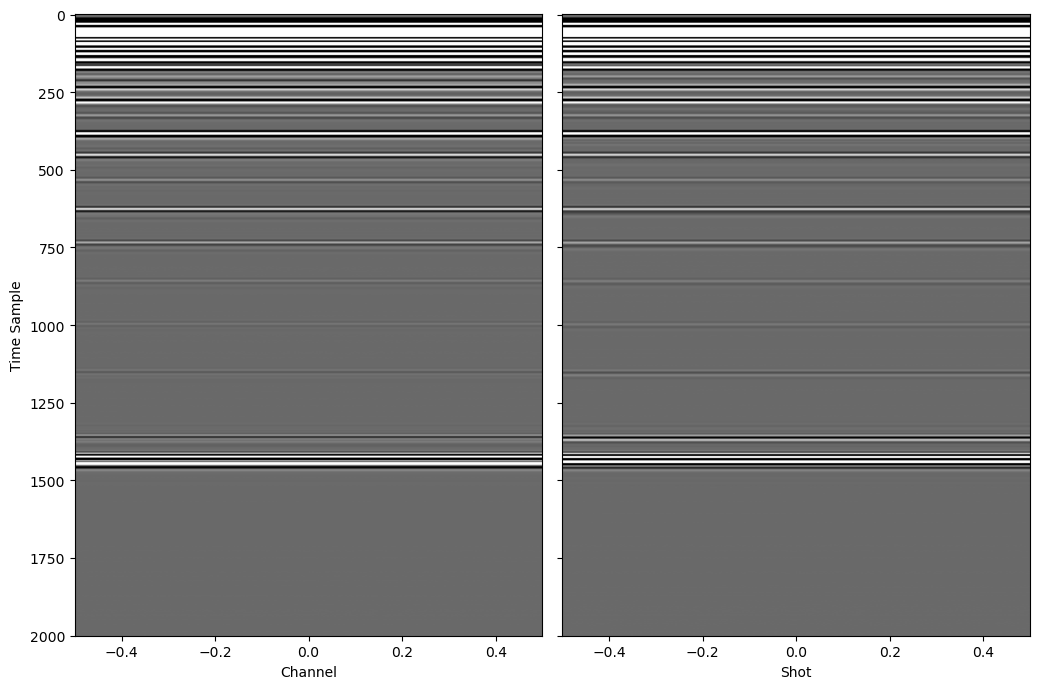

In [16]:
# Simulated receiver amplitudes (the synthetic seismic data)
receiver_amplitudes = out[-1]

# Clip the color scale to the 5th-95th percentile range to improve contrast
vmin, vmax = torch.quantile(
    receiver_amplitudes[0],
    torch.tensor([0.05, 0.95]).to(device),
)
_, ax = plt.subplots(1, 2, figsize=(10.5, 7), sharey=True)

# Common shot gather: all channels recorded for the first shot
ax[0].imshow(
    receiver_amplitudes[0].cpu().detach().numpy().T,
    aspect="auto",
    cmap="gray_r",
    vmin=vmin,
    vmax=vmax,
)
# Common receiver gather: the same receiver recorded across all shots
ax[1].imshow(
    receiver_amplitudes[-1].cpu().detach().numpy().T,
    aspect="auto",
    cmap="gray_r",
    vmin=vmin,
    vmax=vmax,
)
ax[0].set_xlabel("Channel")
ax[0].set_ylabel("Time Sample")
ax[1].set_xlabel("Shot")

plt.tight_layout()
plt.show()


### Combined overview: velocity model and modeled gathers

This cell produces a single figure summarizing the forward-modeling run: the velocity model with the source and receiver positions overlaid, alongside the shot gather for the first receiver and the receiver gather for the last receiver. At the end, the elapsed time since the timer was started earlier in the notebook (`time1`) is reported, giving a sense of the total runtime of the geometry setup and wave propagation.

Function took 0.017 minutes


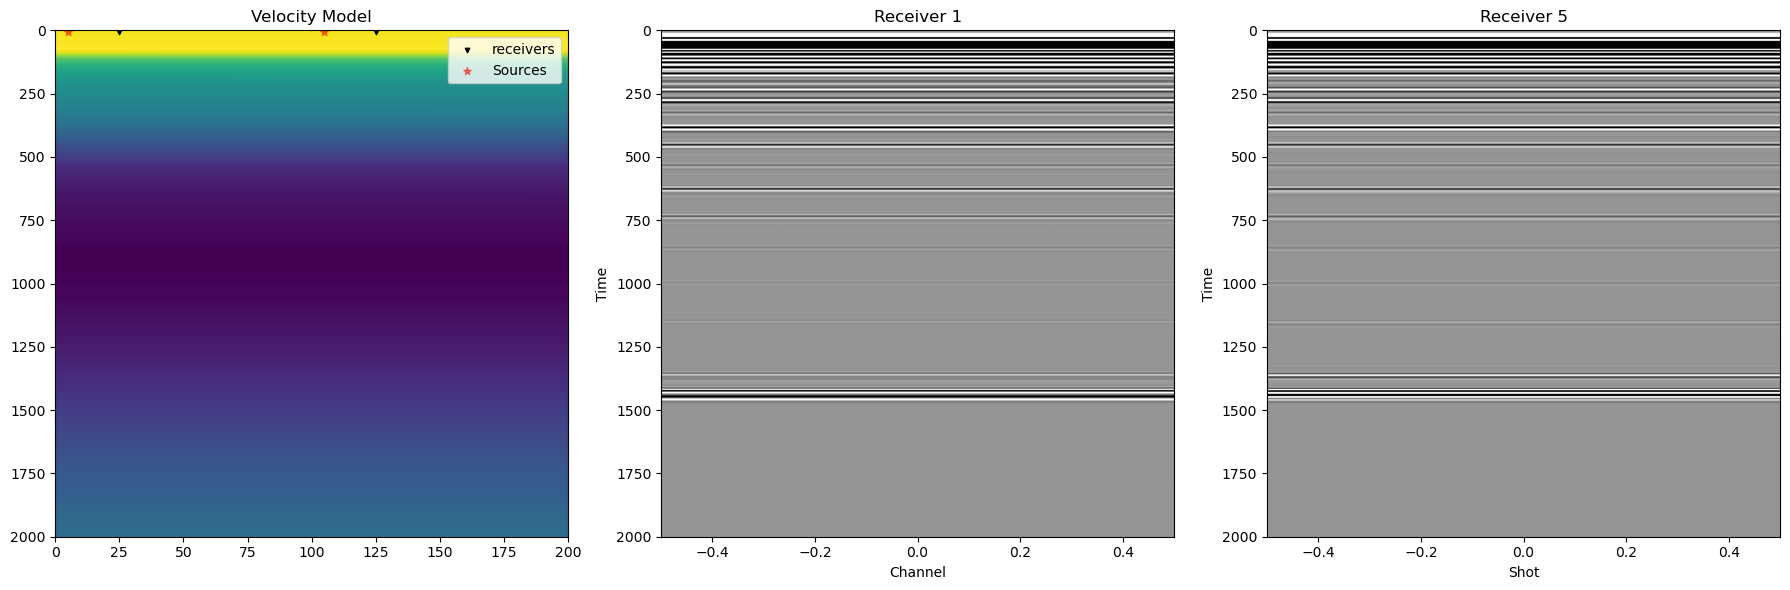

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Velocity model plot
im = axes[0].imshow(v.cpu().detach().numpy(), cmap="viridis",aspect="auto",extent=[0,nx*dx[1],ny*dx[1],0])
axes[0].set_title("Velocity Model")


# -------------------------
# Plotting R E C E I V E R S
# -------------------------

for rec_x,rec_y in zip(receiver_locations[..., 1].cpu().detach().numpy(),receiver_locations[..., 0].cpu().detach().numpy()):
    axes[0].scatter(rec_x*dx[1],rec_y*dx[0], c='black', s=10, marker='v')
axes[0].scatter([],[], c='black', s=10, marker='v', label="receivers")

# -------------------------
# Plotting S O U R C E S
# -------------------------

for src_x,src_y in zip(source_locations[..., 1].cpu(),source_locations[..., 0].cpu()):
    axes[0].scatter(src_x*dx[1],src_y*dx[0], c='red', s=30, marker='*',alpha=0.5)
axes[0].scatter([],[], c='red', s=30, marker='*', label="Sources",alpha=0.5)
axes[0].legend(loc="upper right")

# ------------------------------
# 2. Common shot gather plot
# ------------------------------
receiver_amplitudes = out[-1]

vmin, vmax = torch.quantile(receiver_amplitudes[0], torch.tensor([0.05, 0.95]).to(device))
axes[1].imshow(receiver_amplitudes[0].cpu().detach().numpy().T, aspect="auto", cmap="gray",
               vmin=vmin, vmax=vmax)
axes[1].set_title("Receiver 1")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Time")

# ------------------------------
# 3. Common receiver gather plot
# ------------------------------
axes[2].imshow(receiver_amplitudes[-1].cpu().detach().numpy().T, aspect="auto", cmap="gray",
               vmin=vmin, vmax=vmax)
axes[2].set_title("Receiver 5")
axes[2].set_xlabel("Shot")
axes[2].set_ylabel("Time")

plt.tight_layout()

# Report the total elapsed time since the timer was started earlier in the notebook
time2 = time.time()
elapsed_minutes = (time2 - time1) / 60.0
print("Function took {:.3f} minutes".format(elapsed_minutes))


# Exporting the synthetic data to Zarr

Finally, the simulated ("observed") data and its acquisition metadata are packaged into a labeled `xarray.Dataset` and written to disk in the [Zarr](https://zarr.dev/) format, so that they can be easily reloaded by later stages of the inversion pipeline (e.g., the FWI notebook) without needing to rerun the forward simulation.

Steps performed:

1. The receiver amplitudes are moved from the PyTorch tensor (GPU/CPU, with gradient tracking) to a plain NumPy `float32` array.
2. A time axis is built from `nt` and `dt`.
3. Source and receiver coordinates are converted from grid indices to physical units (meters) by multiplying by the grid spacing `dx`. Deepwave internally orders indices as `[depth, horizontal]`; here `sy`/`gy` represent the depth (Z) coordinate and `sx`/`gx` the horizontal (X) coordinate, to keep them consistent with the notebook's own naming convention.
4. The source-receiver offset (Euclidean distance, in meters) is computed for each shot/receiver pair.
5. All of this is assembled into an `xarray.Dataset` with dimensions `(shot, receiver, time)` for the `amplitude` data variable, and `sx`, `sy`, `gx`, `gy`, `offset` stored as coordinates.
6. The dataset is written to disk as a Zarr store (`ocean_data_synthetic.zarr`), which serves as the observed dataset for the inversion workflow.

In [18]:
# -----------------------------------------------------------------------
# Preparing the data for Xarray and saving it to Zarr
# -----------------------------------------------------------------------

# 1. Extract the data from PyTorch to NumPy
data_np = receiver_amplitudes.cpu().detach().numpy().astype("float32")

# 2. Build the time axis
time_np = np.arange(nt) * dt

# 3. Extract the coordinates and convert them from grid indices to meters (* dx)
# Deepwave works in the [depth, horizontal] order. We keep Z as Y to match the
# notebook's original naming convention
sx_np = source_locations[:, 0, 1].cpu().detach().numpy()* dx[1]  # X coordinate of the sources
sy_np = source_locations[:, 0, 0].cpu().detach().numpy() * dx[0]  # Z(Y) coordinate of the sources

gx_np = receiver_locations[:, :, 1].cpu().detach().numpy() * dx[1]  # X coordinate of the receivers
gy_np = receiver_locations[:, :, 0].cpu().detach().numpy() * dx[0]  # Z(Y) coordinate of the receivers

# 4. Compute the offset (source-receiver distance) in meters
# sx_np[:, None] allows the vectorized operation between (n_shots, 1) and (n_shots, n_receivers)
offset_np = np.sqrt((gx_np - sx_np[:, None])**2 + (gy_np - sy_np[:, None])**2)

# 5. Build the xarray.Dataset
ds = xr.Dataset(
    {
        "amplitude": (("shot", "receiver", "time"), data_np),
    },
    coords={
        "shot": np.arange(n_shots),
        "receiver": np.arange(n_receivers_per_shot),
        "time": time_np,
        "sx": ("shot", sx_np),
        "sy": ("shot", sy_np),
        "gx": (("shot", "receiver"), gx_np),
        "gy": (("shot", "receiver"), gy_np),
        "offset": (("shot", "receiver"), offset_np),
    },
)

# 6. Save the dataset to disk in Zarr format
zarr_filename = "ocean_data_synthetic.zarr"
ds.to_zarr(data_path+zarr_filename, mode="w")

print(f"\nData successfully saved to: {zarr_filename}")
print(ds)



Data successfully saved to: ocean_data_synthetic.zarr
<xarray.Dataset> Size: 32kB
Dimensions:    (shot: 2, receiver: 1, time: 2001)
Coordinates:
  * shot       (shot) int64 16B 0 1
  * receiver   (receiver) int64 8B 0
  * time       (time) float64 16kB 0.0 0.002 0.004 0.006 ... 3.996 3.998 4.0
    sx         (shot) int64 16B 5 105
    sy         (shot) int64 16B 5 5
    gx         (shot, receiver) int64 16B 25 125
    gy         (shot, receiver) int64 16B 5 5
    offset     (shot, receiver) float64 16B 20.0 20.0
Data variables:
    amplitude  (shot, receiver, time) float32 16kB 1.207e-08 ... -5.05e-09


/home/sysop/Programs/anaconda3/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
